First 5 rows of the dataset:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  FEMALE  

Dataset after preprocessing:
   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g species
0            39.1           18.7              181.0       3750.0  Adelie
1            39.5           17.4              186.0       3800.0  Adelie
2            40.3           18.0              195.0       3250.0  Adelie
4            36.7           19.3              193.0   

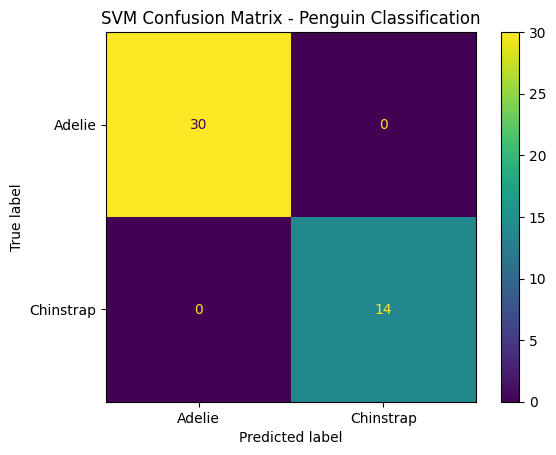

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# --------------------------------------------------
# Loading the Palmer Penguins dataset
# --------------------------------------------------

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"

dataset = pd.read_csv(url)

print("First 5 rows of the dataset:")
print(dataset.head())

print("\n" + "=" * 50)

# --------------------------------------------------
# Creating a Binary Classification Dataset
# Adelie vs Chinstrap
# --------------------------------------------------

dataset = dataset[
    dataset["species"].isin(["Adelie", "Chinstrap"])
]

# Selecting required features
dataset = dataset[
    [
        "bill_length_mm",
        "bill_depth_mm",
        "flipper_length_mm",
        "body_mass_g",
        "species"
    ]
]

# Removing missing values
dataset = dataset.dropna()

print("Dataset after preprocessing:")
print(dataset.head())

print("\nNumber of samples:", len(dataset))

print("\n" + "=" * 50)

# --------------------------------------------------
# Separating Features and Target
# --------------------------------------------------

X = dataset.drop("species", axis=1)

y = dataset["species"]

# Encoding species names into numbers
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("Class Labels:")
for i, class_name in enumerate(encoder.classes_):
    print(i, "=", class_name)

print("\n" + "=" * 50)

# --------------------------------------------------
# Splitting into Training and Testing Data
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# Feature Scaling
# --------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --------------------------------------------------
# Creating and Optimizing the SVM Model
# --------------------------------------------------

svm = SVC()

# Parameters to test
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

# Grid Search for parameter optimization
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

# Training the model
grid_search.fit(X_train, y_train)

# Best SVM model
best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_ * 100, "%")

print("\n" + "=" * 50)

# --------------------------------------------------
# Making Predictions
# --------------------------------------------------

y_pred = best_model.predict(X_test)

print("Predicted Results:")
print(y_pred)

print("\nActual Results:")
print(y_test)

print("\n" + "=" * 50)

# --------------------------------------------------
# Evaluating the Model
# --------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy * 100, "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

print("\n" + "=" * 50)

# Classification Report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

# --------------------------------------------------
# Visualizing the Confusion Matrix
# --------------------------------------------------

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

display.plot()

plt.title("SVM Confusion Matrix - Penguin Classification")

plt.show()